In [ ]:
from zipfile import ZipFile
import os
file_name = '../../Data/handwritten-digits-0-9.zip'

extract_folder = '../../Data/dataset'
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)
    print("Extraction completed.")

Extraction completed.


In [ ]:
data_0 = os.listdir('../../Data/dataset/0')
data_1 = os.listdir('../../Data/dataset/1')
data_2 = os.listdir('../../Data/dataset/2')
data_3 = os.listdir('../../Data/dataset/3')
data_4 = os.listdir('../../Data/dataset/4')
data_5 = os.listdir('../../Data/dataset/5')
data_6 = os.listdir('../../Data/dataset/6')
data_7 = os.listdir('../../Data/dataset/7')
data_8 = os.listdir('../../Data/dataset/8')
data_9 = os.listdir('../../Data/dataset/9')

In [ ]:
len(data_0)

2236

In [ ]:
import numpy as np
from PIL import Image

DATASET_PATH = r"D:/ml1/praktikum13/Data/dataset"

X = []
y = []

for label in range(10):  # 0 sampai 9
    folder_path = os.path.join(DATASET_PATH, str(label))
    
    for file in os.listdir(folder_path):
        img_path = os.path.join(folder_path, file)
        
        # buka gambar
        img = Image.open(img_path).convert("L")  # grayscale
        img = img.resize((28, 28))               # samakan ukuran
        
        # jadi array numerik
        img_array = np.array(img)
        img_flat = img_array.flatten() / 255.0  # flatten + normalisasi
        
        X.append(img_flat)
        y.append(label)
        
X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (21555, 784)
Shape of y: (21555,)


In [ ]:
X[:5]

array([[1.        , 1.        , 0.99607843, ..., 0.99607843, 1.        ,
        0.94117647],
       [0.99607843, 0.99607843, 1.        , ..., 0.99607843, 1.        ,
        0.71372549],
       [0.97647059, 0.98039216, 0.98823529, ..., 0.99215686, 0.99215686,
        0.99215686],
       [0.99215686, 0.99215686, 0.98823529, ..., 0.99607843, 0.99215686,
        0.96862745],
       [0.86666667, 0.98431373, 1.        , ..., 1.        , 1.        ,
        1.        ]], shape=(5, 784))

In [ ]:
y[:5]

array([0, 0, 0, 0, 0])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (17244, 784) (17244,)
Testing set shape: (4311, 784) (4311,)


### Membangun arsitektur hidden layer

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Hidden Layer 1 (16 neuron)
model.add(Dense(
    16, 
    activation='relu', 
    input_shape=(X_train.shape[1],)
))

# Hidden Layer 2 (8 neuron)
model.add(Dense(
    8, 
    activation='relu'
))

# Output Layer (10 neuron untuk angka 0–9)
model.add(Dense(
    10, 
    activation='softmax'
))

model.summary()


c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,786 (49.95 KB)

 Trainable params: 12,786 (49.95 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,786 (49.95 KB)

 Trainable params: 12,786 (49.95 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1046 - loss: 2.3031 - val_accuracy: 0.0909 - val_loss: 2.3026
Epoch 2/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1069 - loss: 2.3022 - val_accuracy: 0.0909 - val_loss: 2.3028
Epoch 3/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1069 - loss: 2.3022 - val_accuracy: 0.0909 - val_loss: 2.3028
Epoch 4/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1069 - loss: 2.3022 - val_accuracy: 0.0909 - val_loss: 2.3032
Epoch 5/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1069 - loss: 2.3021 - val_accuracy: 0.0909 - val_loss: 2.3030
Epoch 6/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1069 - loss: 2.3021 - val_accuracy: 0.0909 - val_loss: 2.3029
Epoch 7/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1069 - loss: 2.3021 - val_accuracy: 0.0909 - val_loss: 2.3030
Epoch 8/20
539/539 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1069 - loss: 2.3022 - val_accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)

135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0909 - loss: 2.3031
Loss: 2.3030714988708496
Accuracy: 0.09093017876148224


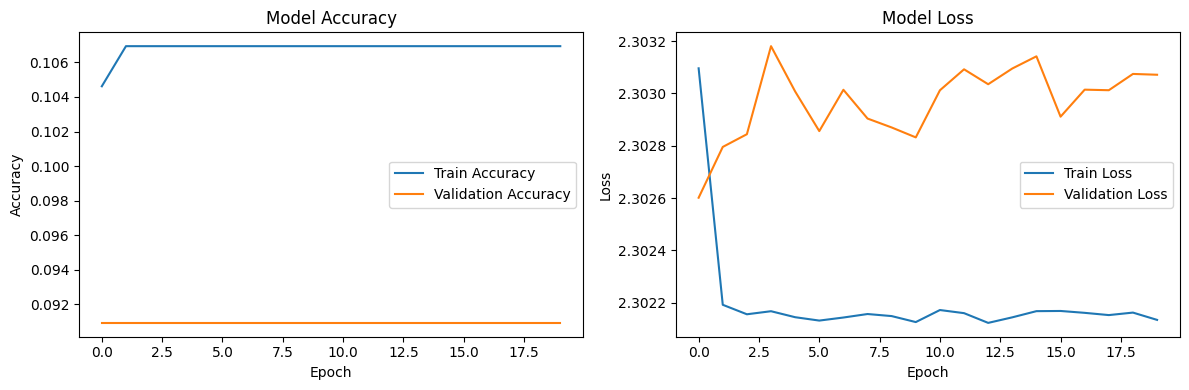

In [ ]:
import matplotlib.pyplot as plt

# Visualisasi Accuracy dan Loss

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()
